In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Função de Rosenbrock

def f(x, y):
    return 100*(y - x**2)**2 + (1 - x)**2


# Gradiente

def grad(x, y):

    df_dx = -400*x*(y - x**2) + 2*(x - 1)

    df_dy = 200*(y - x**2)

    return np.array([df_dx, df_dy])


# Hessiana

def hes(x, y):

    h11 = 1200*x**2 - 400*y + 2

    h12 = -400*x

    h21 = -400*x

    h22 = 200

    return np.array([
        [h11, h12],
        [h21, h22]
    ])


# parâmetros

x0 = np.array([-1.2, 1.0])

tol = 1e-6

max_iter = 10000

c = 1e-4
beta = 0.5

In [4]:
# gradiente com armijo
inicio = time.time()
x = x0.copy()

traj_gd_armijo = [x.copy()]
f_hist_gd_armijo = []
grad_hist_gd_armijo = []

nf = ng = nh = 0

for  k in range(max_iter):
  g = grad(x[0],x[1])
  ng += 1

  if np.linalg.norm(g) <= tol:
    break

  d = -g

  alpha = 1.0

  while f(x[0]+alpha*d[0], x[1]+alpha*d[1]) > f(x[0], x[1]) + c*alpha*np.dot(g, d):
    alpha *= 0.9

    nf += 2

  x = x + alpha*d

  traj_gd_armijo.append(x.copy())

  f_hist_gd_armijo.append(f(x[0], x[1]))
  grad_hist_gd_armijo.append(np.linalg.norm(g))

tempo_gd_armijo = time.time() - inicio

iter_gd_armijo = k+1

f_final_gd_armijo = f(x[0], x[1])
grad_final_gd_armijo = np.linalg.norm(grad(x[0], x[1]))
nf_armijo = nf
ng_armijo = ng
nh_armijo = nh

In [5]:
dados = {
    "Método": ["Gradiente Armijo"],
    "Iterações": [iter_gd_armijo],
    "Tempo (s)": [tempo_gd_armijo],
    "f(x final)": [f_final_gd_armijo],
    "||grad|| final": [grad_final_gd_armijo]
}

pd.DataFrame(dados)

,Método,Iterações,Tempo (s),f(x final),||grad|| final
0,Gradiente Armijo,10000,6.292663,9.148944e-07,0.017858


In [6]:
# metodo de Newton
inicio = time.time()
x = x0.copy()

traj_newton = [x.copy()]
f_hist_newton = []
grad_hist_newton = []

nf = ng = nh = 0

for k in range(max_iter):
  g = grad(x[0], x[1])
  H = hes(x[0], x[1])

  ng += 1
  nh += 1

  if np.linalg.norm(g) <= tol:
    break

  d = -np.linalg.inv(H) @ g
  x = x + d

  traj_newton.append(x.copy())

  f_hist_newton.append(f(x[0], x[1]))
  grad_hist_newton.append(np.linalg.norm(g))

  nf += 1

tempo_newton = time.time() - inicio
iter_newton = k+1

f_final_newton = f(x[0],x[1])
grad_final_newton = np.linalg.norm(grad(x[0],x[1]))
nf_newton = nf
ng_newton = ng
nh_newton = nh

In [7]:
dados = {
    "Método": ["Método Newton"],
    "Iterações": [iter_newton],
    "Tempo (s)": [tempo_newton],
    "f(x final)": [f_final_newton],
    "||grad|| final": [grad_final_newton]
}

pd.DataFrame(dados)

,Método,Iterações,Tempo (s),f(x final),||grad|| final
0,Método Newton,7,0.014084,3.432646e-20,8.285706e-09


In [8]:
# BFGS

x = x0.copy()

n = len(x)

H = np.eye(n)

traj_bfgs = [x.copy()]
f_hist_bfgs = []
grad_hist_bfgs = []

nf = ng = nh = 0

inicio = time.time()

for k in range(max_iter):

    g = grad(x[0], x[1])
    ng += 1

    if np.linalg.norm(g) <= tol:
        break

    d = -H @ g

    alpha = 1.0

    while f(x[0]+alpha*d[0], x[1]+alpha*d[1]) > \
          f(x[0], x[1]) + c*alpha*np.dot(g,d):

        alpha *= 0.9
        nf += 2

    x_new = x + alpha*d

    s = x_new - x

    g_new = grad(x_new[0], x_new[1])
    ng += 1

    y = g_new - g

    rho = 1.0/(y @ s)

    I = np.eye(n)
    # Calculo do BFGS
    H = (
        (I - rho*np.outer(s,y))
        @ H
        @ (I - rho*np.outer(y,s))
        + rho*np.outer(s,s)
    )

    x = x_new

    traj_bfgs.append(x.copy())

    f_hist_bfgs.append(f(x[0],x[1]))
    grad_hist_bfgs.append(np.linalg.norm(g_new))

tempo_bfgs = time.time() - inicio

iter_bfgs = k+1

f_final_bfgs = f(x[0],x[1])
grad_final_bfgs = np.linalg.norm(grad(x[0],x[1]))
nf_bfgs = nf
ng_bfgs = ng
nh_bfgs = nh

In [9]:
dados = {
    "Método": ["Método BFGS"],
    "Iterações": [iter_bfgs],
    "Tempo (s)": [tempo_bfgs],
    "f(x final)": [f_final_bfgs],
    "||grad|| final": [grad_final_bfgs]
}

pd.DataFrame(dados)

,Método,Iterações,Tempo (s),f(x final),||grad|| final
0,Método BFGS,21,0.008521,1.206925e-17,1.282745e-07


In [16]:
# Tabela comparativa
tabela = pd.DataFrame({

    'Método': [
        'Gradiente Armijo',
        'Newton',
        'BFGS'
    ],

    'Tempo (s)': [
        tempo_gd_armijo,
        tempo_newton,
        tempo_bfgs
    ],

    'Iterações': [
        iter_gd_armijo,
        iter_newton,
        iter_bfgs
    ],

    'f(x final)': [
        f_final_gd_armijo,
        f_final_newton,
        f_final_bfgs
    ],

    '||∇f|| final': [
        grad_final_gd_armijo,
        grad_final_newton,
        grad_final_bfgs
    ],

    'Avaliações f': [
        nf_armijo,
        nf_newton,
        nf_bfgs
    ]

})

display(tabela)

,Método,Tempo (s),Iterações,f(x final),||∇f|| final,Avaliações f
0,Gradiente Armijo,6.292663,10000,9.148944e-07,1.785778e-02,1209504
1,Newton,0.014084,7,3.432646e-20,8.285706e-09,6
2,BFGS,0.008521,21,1.206925e-17,1.282745e-07,212


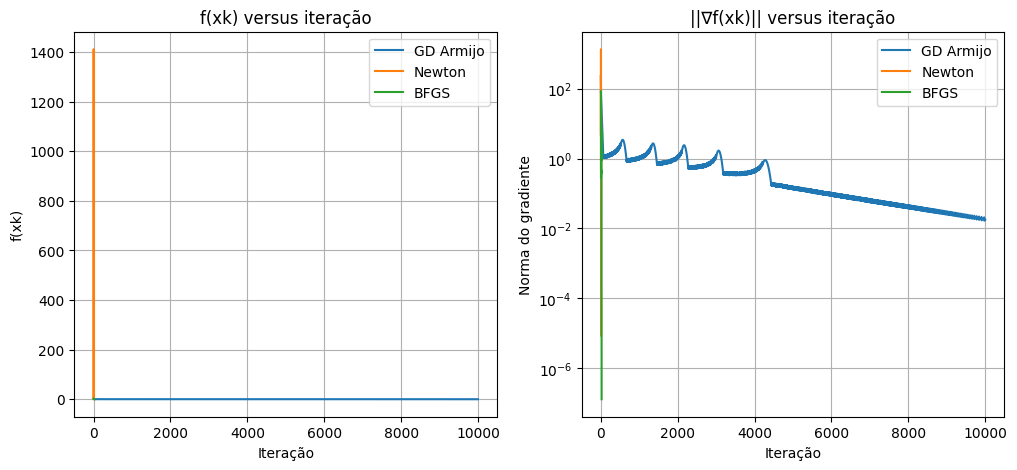

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(f_hist_gd_armijo,label='GD Armijo')
plt.plot(f_hist_newton,label='Newton')
plt.plot(f_hist_bfgs,label='BFGS')

plt.title('f(xk) versus iteração')
plt.xlabel('Iteração')
plt.ylabel('f(xk)')
plt.legend()
plt.grid()

plt.subplot(1,2,2)

plt.semilogy(grad_hist_gd_armijo,label='GD Armijo')
plt.semilogy(grad_hist_newton,label='Newton')
plt.semilogy(grad_hist_bfgs,label='BFGS')

plt.title('||∇f(xk)|| versus iteração')
plt.xlabel('Iteração')
plt.ylabel('Norma do gradiente')
plt.legend()
plt.grid()

plt.show()

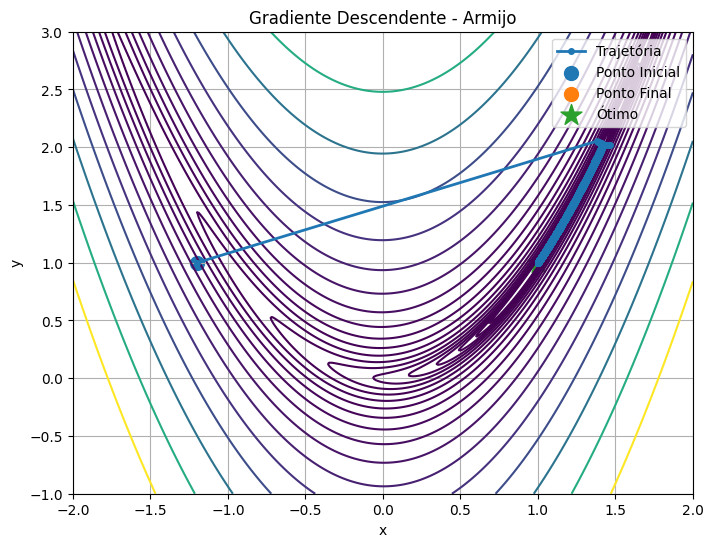

In [12]:
traj = np.array(traj_gd_armijo)

hx = traj[:,0]
hy = traj[:,1]

fig, ax = plt.subplots(figsize=(8,6))

x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x_range, y_range)

Z = 100*(Y - X**2)**2 + (1 - X)**2

ax.contour(
    X,
    Y,
    Z,
    levels=np.logspace(-1, 3, 20),
    cmap='viridis'
)

ax.plot(
    hx,
    hy,
    '-o',
    markersize=4,
    linewidth=2,
    label='Trajetória'
)

ax.scatter(
    hx[0],
    hy[0],
    s=100,
    label='Ponto Inicial'
)

ax.scatter(
    hx[-1],
    hy[-1],
    s=100,
    label='Ponto Final'
)

ax.scatter(
    1,
    1,
    marker='*',
    s=250,
    label='Ótimo'
)

ax.set_title('Gradiente Descendente - Armijo')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True)

plt.show()

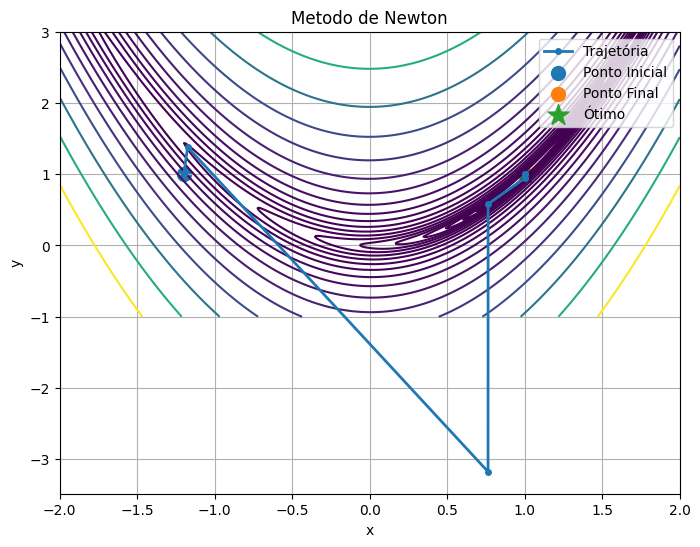

In [13]:
traj = np.array(traj_newton)

hx = traj[:,0]
hy = traj[:,1]

fig, ax = plt.subplots(figsize=(8,6))

x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x_range, y_range)

Z = 100*(Y - X**2)**2 + (1 - X)**2

ax.contour(
    X,
    Y,
    Z,
    levels=np.logspace(-1, 3, 20),
    cmap='viridis'
)

ax.plot(
    hx,
    hy,
    '-o',
    markersize=4,
    linewidth=2,
    label='Trajetória'
)

ax.scatter(
    hx[0],
    hy[0],
    s=100,
    label='Ponto Inicial'
)

ax.scatter(
    hx[-1],
    hy[-1],
    s=100,
    label='Ponto Final'
)

ax.scatter(
    1,
    1,
    marker='*',
    s=250,
    label='Ótimo'
)

ax.set_title('Metodo de Newton')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True)

plt.show()

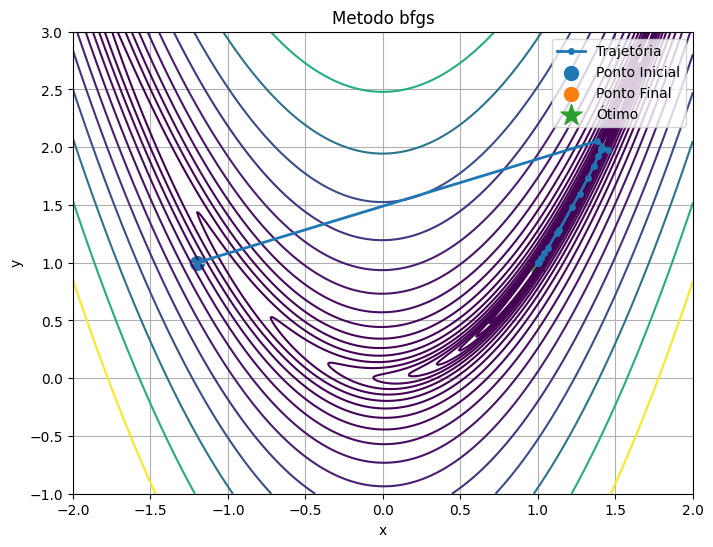

In [14]:
traj = np.array(traj_bfgs)

hx = traj[:,0]
hy = traj[:,1]

fig, ax = plt.subplots(figsize=(8,6))

x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x_range, y_range)

Z = 100*(Y - X**2)**2 + (1 - X)**2

ax.contour(
    X,
    Y,
    Z,
    levels=np.logspace(-1, 3, 20),
    cmap='viridis'
)

ax.plot(
    hx,
    hy,
    '-o',
    markersize=4,
    linewidth=2,
    label='Trajetória'
)

ax.scatter(
    hx[0],
    hy[0],
    s=100,
    label='Ponto Inicial'
)

ax.scatter(
    hx[-1],
    hy[-1],
    s=100,
    label='Ponto Final'
)

ax.scatter(
    1,
    1,
    marker='*',
    s=250,
    label='Ótimo'
)

ax.set_title('Metodo bfgs')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True)

plt.show()